# 06 · Motor imagery: a first decoder

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Decode imagined left versus right hand movement with spectral features and leave-one-run-out validation.

**Data:** MNE EEGBCI subject 1, imagery runs 4/8/12

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

Can imagined left- and right-hand movement be distinguished by the power of sensorimotor rhythms? We first turn a sinusoid into a defensible numerical feature, then test a simple model on a different recording run.

### By the end you should be able to

- Connect sinusoid amplitude, variance and power spectral density.
- Integrate band power with the correct frequency-bin width.
- Build a trial × feature table from channel × time epochs.
- Explain why scaling and classifier fitting belong inside grouped validation.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

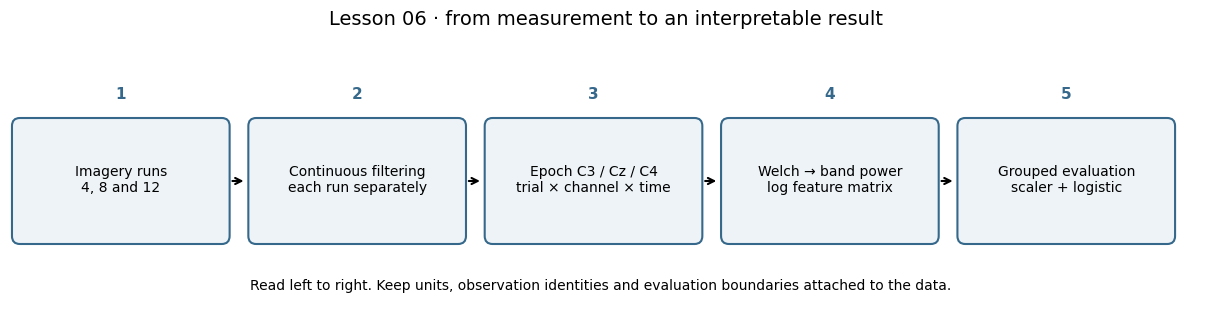

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Imagery runs\n4, 8 and 12', 'Continuous filtering\neach run separately', 'Epoch C3 / Cz / C4\ntrial × channel × time', 'Welch → band power\nlog feature matrix', 'Grouped evaluation\nscaler + logistic']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 06 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Imagery runs: 4, 8 and 12 → Continuous filtering: each run separately → Epoch C3 / Cz / C4: trial × channel × time → Welch → band power: log feature matrix → Grouped evaluation: scaler + logistic.

## Symbols and a calculation by hand

$S(f)$: PSD in V²/Hz; $\Delta f$: frequency spacing; $P$: integrated band power; $z$: log-power feature.

### Derive the operation before calling the library

A unit-amplitude sinusoid has average squared value $1/2$ over complete cycles. Amplitude 2 gives power $2^2/2=2$, a fourfold increase. For a density spectrum, $P\approx\sum_kS(f_k)\Delta f$ over the chosen band. A density of 2 V²/Hz over 3 Hz integrates to 6 V².

Log power $z=\ln(P+\epsilon)$ compresses multiplicative differences: $\ln(4P)-\ln(P)=\ln4$. The real example uses mu 8–13 Hz and beta 13–30 Hz with trapezoidal integration. The shared 13 Hz boundary is an integration endpoint, not an independently counted full-width bin in each band. Keep feature ordering explicit: all selected channels for mu, then all for beta.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### From motor physiology to a measurable feature

Motor imagery involves imagining movement without performing it. Changes in sensorimotor mu and beta activity can be informative, but they are not a guaranteed switch present in every trial. C3 and C4 are useful sensor-level landmarks over opposite sides of the scalp. The expected relationship is a hypothesis to test, not a reason to relabel an inconvenient result. Eye movements, muscle tension or cue differences can also predict class.

A zero-mean sinusoid $x(t)=A\sin(2\pi ft)$ has mean-square power $A^2/2$ over complete cycles. Doubling amplitude quadruples power. For arbitrary EEG, a power spectral density distributes variance across frequency. A density in V²/Hz must be integrated over frequency to yield V²:

$$P_{[f_1,f_2]}\approx\sum_{k\in K}S_{xx}(f_k)\Delta f.$$

For uniformly spaced frequencies, `sum(psd[mask]) * df` is a rectangular approximation. Trapezoidal integration is another approximation; state the convention and keep it consistent. A sum without the frequency step changes when spectral resolution changes.

### Welch estimation and its tradeoff

Welch's method divides the signal into overlapping windows, applies a taper, estimates each spectrum and averages the estimates. Averaging stabilizes the spectrum at the cost of temporal localization. Longer windows give more closely spaced frequency bins, but fewer windows are available for averaging in a fixed-length epoch. Zero padding adds interpolated spectral samples; it does not create new independent information.

Mu and beta boundaries vary across studies and participants. The fixed 8–13 Hz and 13–30 Hz bands here establish a reproducible baseline. If you tune their edges, do so using training folds. Selecting bands from the held-out run converts that run into development data.

### Why logarithms and a linear classifier?

Band powers are nonnegative and often highly skewed. Taking $z=\log(P+\epsilon)$ compresses large values and turns multiplicative differences into additive differences. The small positive floor protects the logarithm; it is a numerical safeguard, not an extra source of power. A change of units adds a constant in log space, so the feature convention must be preserved at deployment.

For logistic regression, the score is $s=w^Tz+b$ and the estimated probability is $\sigma(s)=1/(1+e^{-s})$. The model learns weights from labeled training trials. Standardization uses training means and standard deviations; the test run is transformed using those fixed quantities. A pipeline ensures that cross-validation refits both scaling and the model inside each fold.

Our unit of generalization is a held-out run from one participant. It is weaker than testing a new participant or a new day. Keep that scope in the conclusion even if a score looks impressive.

## Visual intuition · Shade the area that becomes a band-power feature

**Try it:** Read the PSD units and the width of each band. Why is the area, rather than peak height alone, the feature?

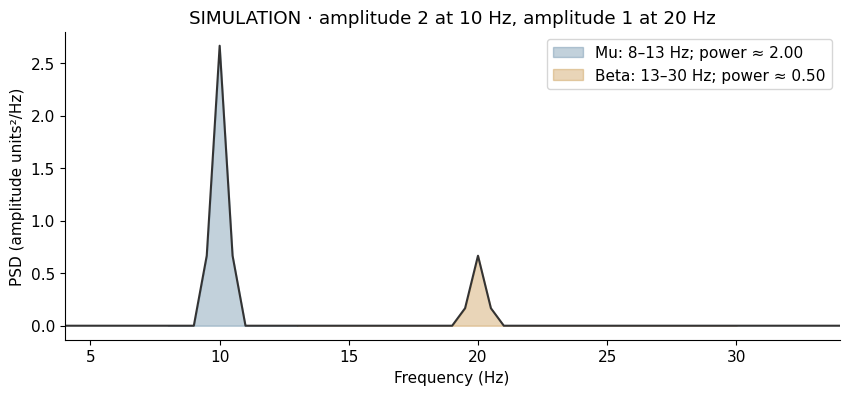

In [3]:
vis_t=np.arange(512)/128
vis_signal=2*np.sin(2*np.pi*10*vis_t)+np.sin(2*np.pi*20*vis_t)
vis_f,vis_psd=signal.welch(vis_signal,fs=128,nperseg=256)
fig,ax=plt.subplots(figsize=(10,4));ax.plot(vis_f,vis_psd,color='#333')
for low,high,color,label in [(8,13,'#35688a','Mu: 8–13 Hz'),(13,30,'#b87714','Beta: 13–30 Hz')]:
    selected=(vis_f>=low)&(vis_f<=high)
    band=np.trapezoid(vis_psd[selected],vis_f[selected])
    ax.fill_between(vis_f,0,vis_psd,where=selected,color=color,alpha=.3,label=f'{label}; power ≈ {band:.2f}')
ax.set(xlim=(4,34),xlabel='Frequency (Hz)',ylabel='PSD (amplitude units²/Hz)',title='SIMULATION · amplitude 2 at 10 Hz, amplitude 1 at 20 Hz')
ax.legend();plt.show()

### Worked interpretation

Expected powers are approximately 2 and 0.5, matching A²/2 for each sinusoid. Power is an integrated quantity. The real-data feature uses the same logic on noisy EEG and then takes its natural logarithm.

## Guided practice 1 · amplitude versus power

Compare two complete-cycle signals differing only in amplitude. Predict the power ratio.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_t=np.arange(1000)/100
demo_small=np.sin(2*np.pi*10*demo_t)
demo_large=2*demo_small
print('Power ratio:',np.mean(demo_large**2)/np.mean(demo_small**2))
assert np.isclose(np.var(demo_large)/np.var(demo_small),4)

Power ratio: 4.0


### Why this result makes sense

Amplitude and power have different units and scale differently. A factor of two in voltage is not a factor of two in power.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · integrate a density

Estimate the power of a known 10 Hz sinusoid by integrating its Welch spectrum.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_f,demo_psd=signal.welch(demo_small,fs=100,nperseg=200)
demo_power=np.sum(demo_psd)*(demo_f[1]-demo_f[0])
print('Time-domain mean square:',np.mean(demo_small**2),'Integrated PSD:',demo_power)
assert np.isclose(demo_power,.5,atol=.01)

Time-domain mean square: 0.4999999999999995 Integrated PSD: 0.49999999999999944


### Why this result makes sense

Agreement provides a unit and normalization check before computing physiological band features.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · construct a feature row

Build mu and beta powers for three artificial channels. Read the output shape aloud and associate each value with its channel and band.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_signals=np.stack([demo_small,2*demo_small,np.sin(2*np.pi*20*demo_t)])
demo_f,demo_psd=signal.welch(demo_signals,fs=100,nperseg=200,axis=-1)
demo_features=np.stack([demo_psd[:,(demo_f>=lo)&(demo_f<=hi)].sum(axis=1)*(demo_f[1]-demo_f[0]) for lo,hi in [(8,12),(13,30)]],axis=1)
print(pd.DataFrame(demo_features,index=['channel A','channel B','channel C'],columns=['mu','beta']))

                     mu          beta
channel A  5.000000e-01  1.313254e-28
channel B  2.000000e+00  5.253016e-28
channel C  2.132443e-28  5.000000e-01


### Why this result makes sense

The channel × band matrix becomes one flattened feature row for one trial. Preserve the column order when applying a trained model.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · log power differences

Take two powers with a known ratio. Show why their log difference depends on the ratio rather than the absolute scale.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_p=np.array([1.,4.])
print('Natural-log difference:',np.diff(np.log(demo_p))[0])
print('Power ratio in dB:',10*np.log10(demo_p[1]/demo_p[0]))
assert np.isclose(np.diff(np.log(demo_p))[0],np.log(4))

Natural-log difference: 1.3862943611198906
Power ratio in dB: 6.020599913279624


### Why this result makes sense

Natural log and decibels are related but not identical numerical features. Name the transformation instead of writing simply “normalized power.”

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Power feature

Implement mean_square on the final axis, returning one number per channel/trial. Explain when it equals variance.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def mean_square(values):
    # TODO: reduce the final (time) axis.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def mean_square(values):
    return np.mean(np.asarray(values)**2,axis=-1)

In [10]:
answer=mean_square(np.array([[1.,-1.],[2.,-2.]]))
if answer is not None:
    assert np.allclose(answer,[1.,4.]); print('Power checks passed.')
else: print('Exercise pending: implement mean_square.')

Power checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

Sensorimotor rhythms include mu (roughly 8–13 Hz) and beta (roughly 13–30 Hz) activity. Motor imagery can change their power; activity over contralateral sensorimotor cortex often desynchronizes. These are tendencies, not a guaranteed pattern for every participant. Eye, muscle and cue-related signals can also predict the task.

Band power integrates a PSD: $P_{c,[a,b]}=\int_a^b\hat P_c(f)df$. A feature $z_c=\log(P_c+\epsilon)$ reduces skew. Logistic regression maps $p(y=1|z)=\sigma(w^Tz+b)$ and minimizes cross-entropy plus a penalty on $w$. Standardization must learn its mean and scale from training data only.

Runs 4, 8 and 12 in PhysioNet EEGBCI all represent imagined left/right fist. Runs 6, 10 and 14 instead use hands/feet; mixing them under one T1/T2 label would change the task. We test transfer to a held-out run of the same participant, not to a new person.

## Load runs and preserve groups
Continuous filtering is performed independently within each run before epoching.

Each run is filtered independently before epoch extraction. Run identifiers are attached to every trial and retained after concatenation. This preserves the grouping needed to evaluate transfer beyond the recording block used for fitting.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**3.** Store this intermediate result so the next operation can be traced and inspected.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Make the analysis choice visible and fixed before inspecting evaluation performance.
runs = [4, 8, 12]
# Store this intermediate result so the next operation can be traced and inspected.
parts, groups = ([], [])

### Step 1.2 · trace the next operation

**1.** Process each run independently; carry its run ID into every resulting trial.

In [12]:
# Process each run independently; carry its run ID into every resulting trial.
for run in runs:
    # Retrieve this run independently so filtering does not cross a run boundary.
    paths = eegbci.load_data(1, [run], path=DATA_ROOT, update_path=False)
    # Load this run’s continuous recording and its sampling metadata.
    raw_run = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    # Make sensor names consistent with the montage and later channel selections.
    eegbci.standardize(raw_run)
    # Attach sensor locations; no anatomical inverse model is used.
    raw_run.set_montage('standard_1005')
    # Use the same reference convention for every run.
    raw_run.set_eeg_reference('average', projection=False)
    # Filter the continuous run before extracting its trials.
    raw_run.filter(8, 30, fir_design='firwin')
    # Map only the documented imagery cues to the two class codes.
    events, _ = mne.events_from_annotations(raw_run, event_id={'T1': 1, 'T2': 2})
    # Extract the stated post-cue interval while retaining condition labels.
    ep = mne.Epochs(raw_run, events, {'left': 1, 'right': 2}, tmin=0.5, tmax=3.5, baseline=None, preload=True, picks='eeg', reject_by_annotation=True)
    # Retain this run’s epoch object for the later concatenation.
    parts.append(ep)
    # Append exactly one run identifier for every retained trial.
    groups.extend([run] * len(ep))

/tmp/ipykernel_467805/1290271967.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_467805/1290271967.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')
/tmp/ipykernel_467805/1290271967.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


### Step 1.3 · trace the next operation

**1.** Join trial collections while retaining one aligned group label per trial.

**2.** Expose the numerical array; EEG values are in volts and the final axis is time.

**3.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**4.** Make an explicit NumPy vector while preserving its current row order.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [13]:
# Join trial collections while retaining one aligned group label per trial.
epochs = mne.concatenate_epochs(parts)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
y = epochs.events[:, 2] - 1
# Make an explicit NumPy vector while preserving its current row order.
groups = np.asarray(groups)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Epochs:', X.shape, 'run counts:', pd.Series(groups).value_counts().to_dict())

Epochs: (45, 64, 481) run counts: {4: 15, 8: 15, 12: 15}


/tmp/ipykernel_467805/2710259772.py:2: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(parts)


### Inspect and interpret

Verify all three run identifiers appear and that both classes are represented in each. Read the concatenated shape and confirm labels and groups have one entry per epoch.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Verify the unit of generalization

**Try it:** Print a run-by-class count table and identify what a held-out run measures.

**My reasoning / hand calculation:** _write here._

In [14]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Use groups and y from the same concatenated epochs.

### Worked solution

Run the following calculation after attempting your own version.

In [15]:
print(pd.crosstab(pd.Series(groups,name='run'),pd.Series(y,name='class')))
assert len(X)==len(y)==len(groups)

class  0  1
run        
4      8  7
8      8  7
12     7  8


### Interpret and check

Each run contains trials from the same participant. Holding out a run tests transfer to another block for that participant; it does not test a new person. A balanced table does not guarantee independence or absence of movement confounds.

## Extract mu and beta power
Use C3, Cz and C4 to keep the first model interpretable; this channel set is declared in advance.

Welch spectra are estimated along time for selected sensors. Integrating each predeclared band and taking log power forms an interpretable feature vector. The plot is an inspection tool, not a replacement for held-out evaluation.

### Step 2.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Estimate a density spectrum along time by averaging tapered segment spectra.

**3.** Integrate the density over each frequency band, then compress power with a logarithm.

**4.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [16]:
# Store this intermediate result so the next operation can be traced and inspected.
picks = [epochs.ch_names.index(ch) for ch in ['C3', 'Cz', 'C4']]
# Estimate a density spectrum along time by averaging tapered segment spectra.
f, psd = signal.welch(X[:, picks, :], fs=epochs.info['sfreq'], nperseg=256, axis=-1)
# Integrate the density over each frequency band, then compress power with a logarithm.
features = np.concatenate([np.log(np.maximum(np.trapezoid(psd[:, :, (f >= a) & (f <= b)], f[(f >= a) & (f <= b)], axis=-1), 1e-30)) for a, b in [(8, 13), (13, 30)]], axis=1)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Feature matrix:', features.shape)

Feature matrix: (45, 6)


### Step 2.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

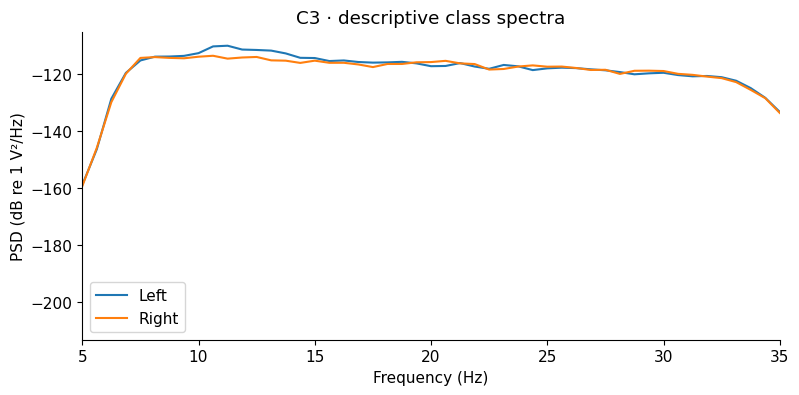

In [17]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Plot each named condition on comparable axes without changing its observations.
for label, name in [(0, 'Left'), (1, 'Right')]:
    ax.plot(f, 10 * np.log10(psd[y == label, 0].mean(0)), label=name)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlim=(5, 35), xlabel='Frequency (Hz)', ylabel='PSD (dB re 1 V²/Hz)', title='C3 · descriptive class spectra')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Name every feature column and its transformation. Check whether individual-trial distributions overlap even if class means differ. Strong overlap is normal in noisy physiological data.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Name every feature column and inspect overlap

**Try it:** Label the mu and beta features and compare C3 mu distributions by class.

**My reasoning / hand calculation:** _write here._

In [18]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

The concatenate operation places three mu features before three beta features.

### Worked solution

Run the following calculation after attempting your own version.

   C3 mu 8–13 Hz  Cz mu 8–13 Hz  C4 mu 8–13 Hz  C3 beta 13–30 Hz  \
0         -24.49         -24.00         -23.88            -23.83   
1         -25.43         -24.06         -23.91            -23.97   
2         -24.44         -25.00         -25.15            -24.29   

   Cz beta 13–30 Hz  C4 beta 13–30 Hz  
0            -24.19            -23.65  
1            -24.51            -24.31  
2            -24.12            -23.96  


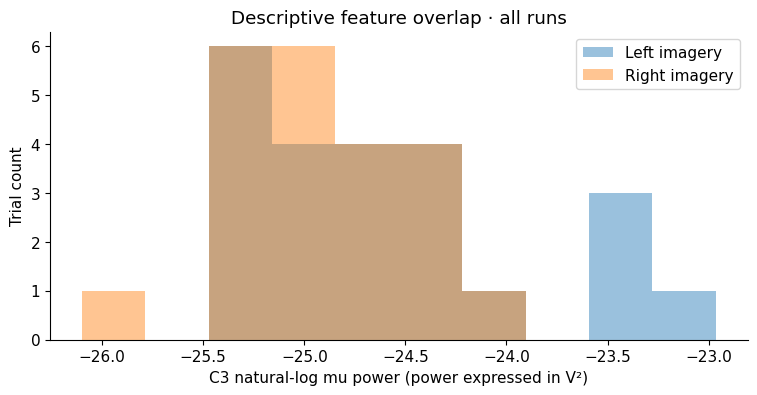

In [19]:
lab_names=[f'{ch} {band}' for band in ['mu 8–13 Hz','beta 13–30 Hz'] for ch in ['C3','Cz','C4']]
print(pd.DataFrame(features[:3],columns=lab_names).round(2))
fig,ax=plt.subplots(figsize=(9,4))
lab_bins=np.histogram_bin_edges(features[:,0],bins=10)
for label,name in [(0,'Left imagery'),(1,'Right imagery')]:
    ax.hist(features[y==label,0],bins=lab_bins,alpha=.45,label=name)
ax.set(xlabel='C3 natural-log mu power (power expressed in V²)',ylabel='Trial count',title='Descriptive feature overlap · all runs')
ax.legend();plt.show()

### Interpret and check

The histogram shows individual-trial overlap, which a mean spectrum can hide. It is descriptive across all runs and must not be used to tune a feature and then claim the same runs were untouched tests. The column names preserve channel and band order for later model application.

## Evaluate run transfer
Three folds are descriptive repeated measurements, not three independent participants.

The scaler and logistic model are fitted afresh for each grouped fold. Leaving out a complete run asks whether the learned feature relationship survives a new block of recording.

### Step 3.1 · trace the next operation

**1.** Keep learned preprocessing and the classifier inside the same fitting boundary.

**2.** Hold entire recording groups out rather than mixing neighboring trials.

**3.** Clone and refit the whole pipeline for every held-out group.

**4.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**5.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

In [20]:
# Keep learned preprocessing and the classifier inside the same fitting boundary.
model = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=1000, random_state=SEED))
# Hold entire recording groups out rather than mixing neighboring trials.
cv = GroupKFold(n_splits=3)
# Clone and refit the whole pipeline for every held-out group.
result = cross_validate(model, features, y, groups=groups, cv=cv, scoring=['balanced_accuracy', 'roc_auc'], return_train_score=False)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(pd.DataFrame({k: v for k, v in result.items() if k.startswith('test_')}))
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert np.isfinite(result['test_balanced_accuracy']).all()

   test_balanced_accuracy  test_roc_auc
0                0.616071      0.767857
1                0.544643      0.446429
2                0.526786      0.660714


### Inspect and interpret

Report the individual run scores and their spread. Do not treat three folds from one person as three independent participants.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Locate the scaling boundary

**Try it:** Should the scaler be fitted once on all feature rows before GroupKFold? Explain.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Mean and variance are learned parameters too.

### Worked solution

No. Each fold must fit the scaler only on its training rows, then apply those fixed values to the held-out run. A pipeline ensures this happens when cross_validate clones and fits the estimator. Scaling everything first leaks information about the evaluation distribution.

## Practice 5 · Interpret a spectral difference cautiously

**Try it:** Give one neural and one non-neural explanation for a left/right power difference.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

A discriminative feature is not automatically a specific physiological mechanism.

### Worked solution

A neural possibility is lateralized sensorimotor rhythm modulation during imagery. A non-neural possibility is different muscle tension or eye movement associated with the cues. Additional sensors, protocol controls and independent evaluation help distinguish them; classifier accuracy alone does not.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

A band-power feature integrates a density over frequency and usually compresses its scale with a logarithm. A held-out-run pipeline fits both scaling and classification only on training rows. Neural interpretation requires controls beyond prediction accuracy.

## If your result is different

If powers are nonpositive or huge, check PSD density units, integration axis and channel types. If a score is suspiciously high, inspect group overlap and cue/movement confounds.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[EEGBCI dataset and run mapping](https://mne.tools/stable/generated/mne.datasets.eegbci.load_data.html) · [Logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.